# Prueba 2.

La siguiente prueba será realizada sobre el modelo C, el cual mostró ser el modelo más eficiente de todos.
Esta prueba consistirá en silenciar algún submodelo que conforma el modelo C, así como evaluar la funcionalidad de cada submodelo en todo el conjunto de prueba.

### Importación de librerías.

In [1]:
import __main__
from modelo_c import ModeloEnsambladoFraude
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, average_precision_score, ConfusionMatrixDisplay

### Importación de datos.

In [2]:
df = pd.read_csv('datos_sinteticos.csv', sep=";")
df.head(2)

,cliente_id,fechas_hora,montos,tipos_establecimiento,historico_establecimiento,es_anomalia,tipo_anomalia,promedio,desviacion,maximo,minimo,monto_hora,moda_establecimiento,cantidad_establecimiento
0,1,"['2026-06-08 00:16:00', '2026-06-08 06:14:00',...","['705.29', '628.12', '272.24', '382.26', '1109...","['Farmacia', 'Farmacia', 'Transporte', 'Farmac...","['0.16643057183060853', '0.017594963536259', '...",0,Normal,879.374333,602.582962,2380.04,240.25,34.208766,Farmacia,7
1,2,"['2026-06-14 07:11:00', '2026-06-15 07:48:00',...","['266.04', '518.87', '266.71', '193.6', '264.7...","['Otros', 'Otros', 'Transporte', 'Transporte',...","['0.001894439046728334', '0.01438288653067728'...",0,Normal,346.078000,165.763599,762.78,63.60,16.192467,Otros,5


### Eliminando variables no útiles.

In [3]:
df = df.drop(columns=['cliente_id', 'promedio', 'desviacion', 'maximo', 'minimo', 'monto_hora', 'moda_establecimiento', 'cantidad_establecimiento'])
df.head(2)

,fechas_hora,montos,tipos_establecimiento,historico_establecimiento,es_anomalia,tipo_anomalia
0,"['2026-06-08 00:16:00', '2026-06-08 06:14:00',...","['705.29', '628.12', '272.24', '382.26', '1109...","['Farmacia', 'Farmacia', 'Transporte', 'Farmac...","['0.16643057183060853', '0.017594963536259', '...",0,Normal
1,"['2026-06-14 07:11:00', '2026-06-15 07:48:00',...","['266.04', '518.87', '266.71', '193.6', '264.7...","['Otros', 'Otros', 'Transporte', 'Transporte',...","['0.001894439046728334', '0.01438288653067728'...",0,Normal


### Separando las variables predictoras de la objetivo.

In [4]:
X = df.drop(columns = ['es_anomalia'])
y = df['es_anomalia']

### Separación del conjunto de prueba y entrenamiento.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=X['tipo_anomalia'])

### Importación del modelo.

In [7]:
modelo = ModeloEnsambladoFraude(umbral=0.4789, batch_size=256)

### Resultados de predicción.

In [8]:
resultados = modelo.predict(X_test)
resultados.head(2)

,prob_transaccion_corta,etiqueta_transaccion_corta,prob_orden_no_congruente,etiqueta_orden_no_congruente,prob_establecimiento_raro,etiqueta_establecimiento_raro,probabilidad_mayor,codigo_final,prediccion_final
37437,0.000029,0,0.942892,1,0.187749,0,0.942892,2,orden_no_congruente
86866,0.000212,0,0.001157,0,0.039152,0,0.039152,0,Normal


### Función de silenciamiento.

In [14]:
def predicciones(columnas):

    df_silenciado = pd.DataFrame(0, index=resultados.index, columns=["probabilidad", "etiqueta"])

    for i in resultados.index:

        for c1, c2 in columnas:
            if df_silenciado.loc[i, 'probabilidad'] < resultados.loc[i, c1]:
                df_silenciado.loc[i, 'probabilidad'] = resultados.loc[i, c1]
            if df_silenciado.loc[i, 'etiqueta'] < resultados.loc[i, c2]:
                df_silenciado.loc[i, 'etiqueta'] = resultados.loc[i, c2]

    df_silenciado['tipo_anomalia'] = X_test['tipo_anomalia']
    return df_silenciado

## Original.

In [18]:
original = predicciones([('prob_transaccion_corta', 'etiqueta_transaccion_corta'),
                         ('prob_orden_no_congruente', 'etiqueta_orden_no_congruente'),
                         ('prob_establecimiento_raro', 'etiqueta_establecimiento_raro')])

C:\Users\ricro\AppData\Local\Temp\ipykernel_6312\2547388355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.851329008990433e-05' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_silenciado.loc[i, 'probabilidad'] = resultados.loc[i, c1]


### Reconocimiento de tipo de anomalías.

In [19]:
original.groupby('tipo_anomalia')['etiqueta'].mean()

tipo_anomalia
Normal                  0.063324
establecimiento_raro    0.815041
orden_no_congruente     0.978723
transaccion_corta       0.998615
Name: etiqueta, dtype: float64

### Matriz de confusión del conjunto de prueba.

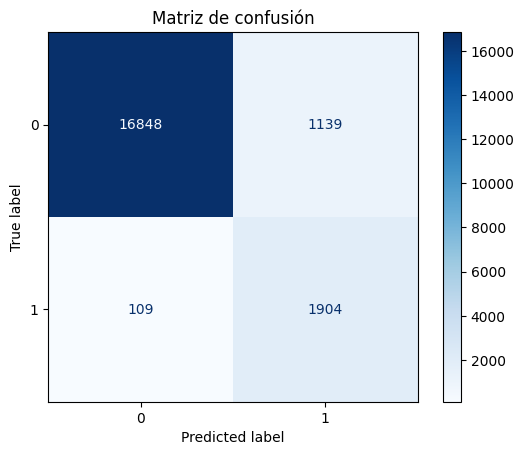

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, original['etiqueta'], cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

## Solo CNN-1D.

In [21]:
cnn = predicciones([('prob_transaccion_corta', 'etiqueta_transaccion_corta')])

C:\Users\ricro\AppData\Local\Temp\ipykernel_6312\2547388355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.851329008990433e-05' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_silenciado.loc[i, 'probabilidad'] = resultados.loc[i, c1]


### Reconocimiento de tipo de anomalías.

In [22]:
cnn.groupby('tipo_anomalia')['etiqueta'].mean()

tipo_anomalia
Normal                  0.005282
establecimiento_raro    0.002033
orden_no_congruente     0.007509
transaccion_corta       0.998615
Name: etiqueta, dtype: float64

### Matriz de confusión del conjunto de prueba.

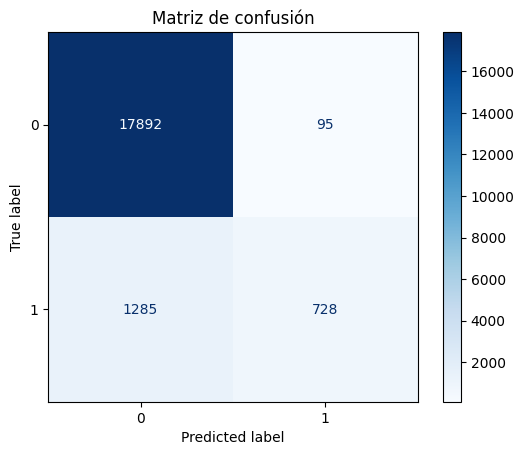

In [23]:
ConfusionMatrixDisplay.from_predictions(y_test, cnn['etiqueta'], cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

## Solo LSTM.

In [26]:
lstm = predicciones([('prob_orden_no_congruente', 'etiqueta_orden_no_congruente')])

C:\Users\ricro\AppData\Local\Temp\ipykernel_6312\2547388355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9428924322128296' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_silenciado.loc[i, 'probabilidad'] = resultados.loc[i, c1]


### Reconocimiento de tipo de anomalías.

In [27]:
lstm.groupby('tipo_anomalia')['etiqueta'].mean()

tipo_anomalia
Normal                  0.023517
establecimiento_raro    0.022358
orden_no_congruente     0.977472
transaccion_corta       0.013850
Name: etiqueta, dtype: float64

### Matriz de confusión del conjunto de prueba.

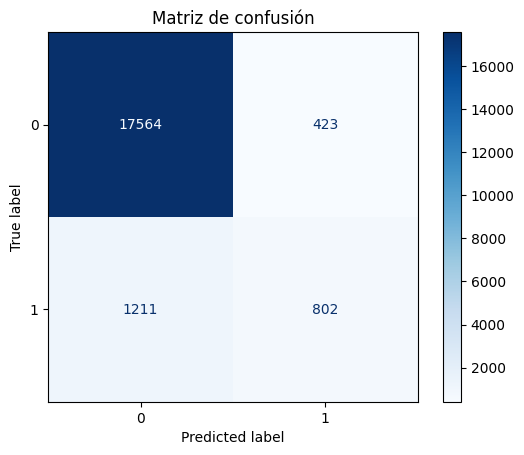

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, lstm['etiqueta'], cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

## Solo RandomForest.

In [29]:
rf = predicciones([('prob_establecimiento_raro', 'etiqueta_establecimiento_raro')])

C:\Users\ricro\AppData\Local\Temp\ipykernel_6312\2547388355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.18774934113025665' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_silenciado.loc[i, 'probabilidad'] = resultados.loc[i, c1]


### Reconocimiento de tipo de anomalías.

In [30]:
rf.groupby('tipo_anomalia')['etiqueta'].mean()

tipo_anomalia
Normal                  0.035470
establecimiento_raro    0.810976
orden_no_congruente     0.036295
transaccion_corta       0.038781
Name: etiqueta, dtype: float64

### Matriz de confusión del conjunto de prueba.

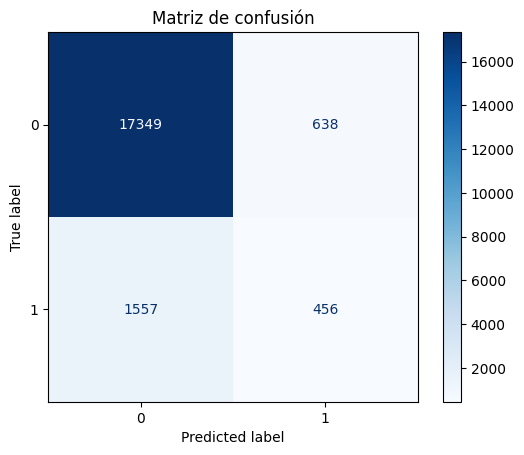

In [32]:
ConfusionMatrixDisplay.from_predictions(y_test, rf['etiqueta'], cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

## Silenciando la CNN-1D.

In [15]:
cnn_silenciada = predicciones([('prob_orden_no_congruente', 'etiqueta_orden_no_congruente'),
                               ('prob_establecimiento_raro', 'etiqueta_establecimiento_raro')])
cnn_silenciada.head(3)

C:\Users\ricro\AppData\Local\Temp\ipykernel_6312\2547388355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.9428924322128296' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_silenciado.loc[i, 'probabilidad'] = resultados.loc[i, c1]


,probabilidad,etiqueta,tipo_anomalia
37437,0.942892,1,orden_no_congruente
86866,0.039152,0,Normal
14366,0.332107,0,Normal


### Reconocimiento de tipo de anomalías.

In [16]:
cnn_silenciada.groupby('tipo_anomalia')['etiqueta'].mean()

tipo_anomalia
Normal                  0.058209
establecimiento_raro    0.815041
orden_no_congruente     0.978723
transaccion_corta       0.052632
Name: etiqueta, dtype: float64

### Matriz de confusión del conjunto de prueba.

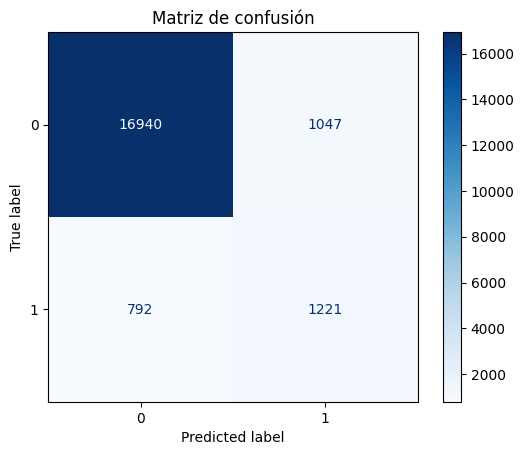

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, cnn_silenciada['etiqueta'], cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

## Silenciando la LSTM.

In [33]:
lstm_silenciada = predicciones([('prob_transaccion_corta', 'etiqueta_transaccion_corta'),
                                ('prob_establecimiento_raro', 'etiqueta_establecimiento_raro')])

C:\Users\ricro\AppData\Local\Temp\ipykernel_6312\2547388355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.851329008990433e-05' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_silenciado.loc[i, 'probabilidad'] = resultados.loc[i, c1]


### Reconocimiento de tipo de anomalías.

In [34]:
lstm_silenciada.groupby('tipo_anomalia')['etiqueta'].mean()

tipo_anomalia
Normal                  0.040640
establecimiento_raro    0.810976
orden_no_congruente     0.043805
transaccion_corta       0.998615
Name: etiqueta, dtype: float64

### Matriz de confusión del conjunto de prueba.

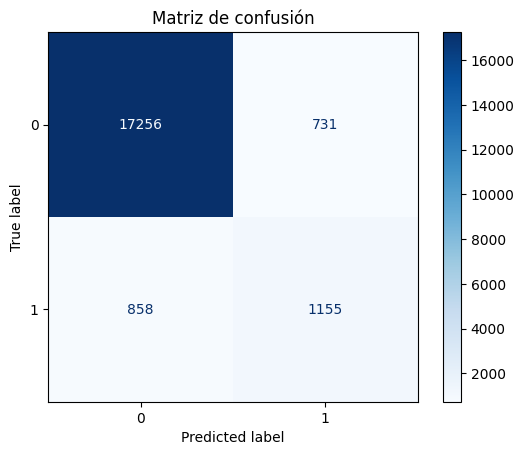

In [35]:
ConfusionMatrixDisplay.from_predictions(y_test, lstm_silenciada['etiqueta'], cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

## Silenciando Random Forest.

In [36]:
rf_silenciada = predicciones([('prob_transaccion_corta', 'etiqueta_transaccion_corta'),
                              ('prob_orden_no_congruente', 'etiqueta_orden_no_congruente')])

C:\Users\ricro\AppData\Local\Temp\ipykernel_6312\2547388355.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.851329008990433e-05' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_silenciado.loc[i, 'probabilidad'] = resultados.loc[i, c1]


### Reconocimiento de tipo de anomalías.

In [37]:
rf_silenciada.groupby('tipo_anomalia')['etiqueta'].mean()

tipo_anomalia
Normal                  0.028743
establecimiento_raro    0.024390
orden_no_congruente     0.977472
transaccion_corta       0.998615
Name: etiqueta, dtype: float64

### Matriz de confusión del conjunto de prueba.

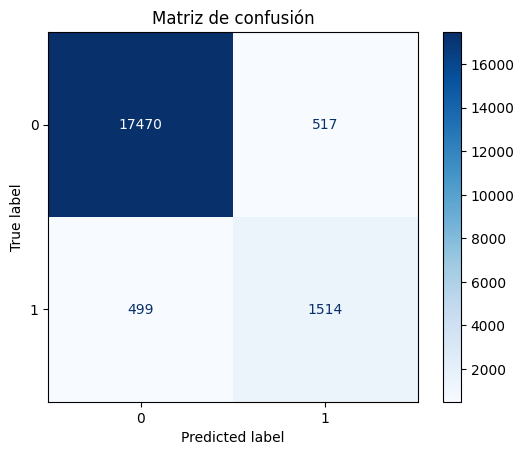

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_silenciada['etiqueta'], cmap="Blues")
plt.title("Matriz de confusión")
plt.show()